# Interannual IKE: Combined 3-Panel Figure

a) Total Annual IKE (stacked bar), b) Average IKE at Landfall (line), c) unstacked bar chart of mean monthly IKE -- all by basin.  



## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import os

import calendar
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe
from ike_climatology.aggregate import get_interannual_ike_metrics
from ike_climatology.style import DESIRED_BASIN_ORDER, BASIN_COLORS


## Data extraction and aggregation

In [3]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

annual_metrics = get_interannual_ike_metrics(
    master_df, pre_et_window_hrs=config.PRE_ET_WINDOW_HRS
)
annual_metrics.head()


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

,basin,storm_year,annual_total_ike,annual_average_ike,annual_avg_peak_ike,annual_avg_genesis_ike,annual_avg_of_avgs_ike,annual_avg_landfall_ike
0,East Pacific,2004,2662.544303,15.848478,24.084269,7.849409,13.994529,NaN
1,East Pacific,2005,3758.731736,15.279397,22.863358,2.774858,11.152417,NaN
2,East Pacific,2006,8170.036671,23.819349,23.163395,5.387610,12.527148,15.417182
3,East Pacific,2007,1172.188961,7.466172,11.391751,1.725981,5.565678,13.936647
4,East Pacific,2008,2424.625736,9.397774,11.866370,1.470197,6.762680,12.951968


## Global summary

Quick sanity check on genesis/landfall IKE before plotting.

In [4]:
yearly_global = (
    annual_metrics.groupby("storm_year")[["annual_avg_genesis_ike", "annual_avg_landfall_ike"]]
    .mean()
)

print("--- Global average by year (mean across basins, TJ) ---")
print(f"  {'Year':<6}{'genesis':>12}{'landfall':>12}")
for year, row in yearly_global.iterrows():
    print(f"  {int(year):<6}{row['annual_avg_genesis_ike']:>12.3f}{row['annual_avg_landfall_ike']:>12.3f}")

print(
    f"\n  GLOBAL           genesis = {annual_metrics['annual_avg_genesis_ike'].mean():8.3f}"
    f"    landfall = {annual_metrics['annual_avg_landfall_ike'].mean():8.3f}"
)


--- Global average by year (mean across basins, TJ) ---
  Year       genesis    landfall
  2004         7.380      29.750
  2005         5.431      14.666
  2006         4.550      17.414
  2007         4.812      26.540
  2008         3.583      18.536
  2009         2.651      19.717
  2010         2.665      15.349
  2011         3.723      19.097
  2012         5.584      23.801
  2013         3.086      16.591
  2014         2.981      25.673
  2015         4.769      19.364
  2016         6.366      24.572
  2017         7.674      23.700
  2018         9.414      26.703
  2019         8.522      26.418
  2020         5.650      16.617
  2021         6.782      17.710
  2022        10.252      21.408
  2023         6.002      18.331
  2024         8.746      16.146

  GLOBAL           genesis =    5.744    landfall =   20.905


## Figure

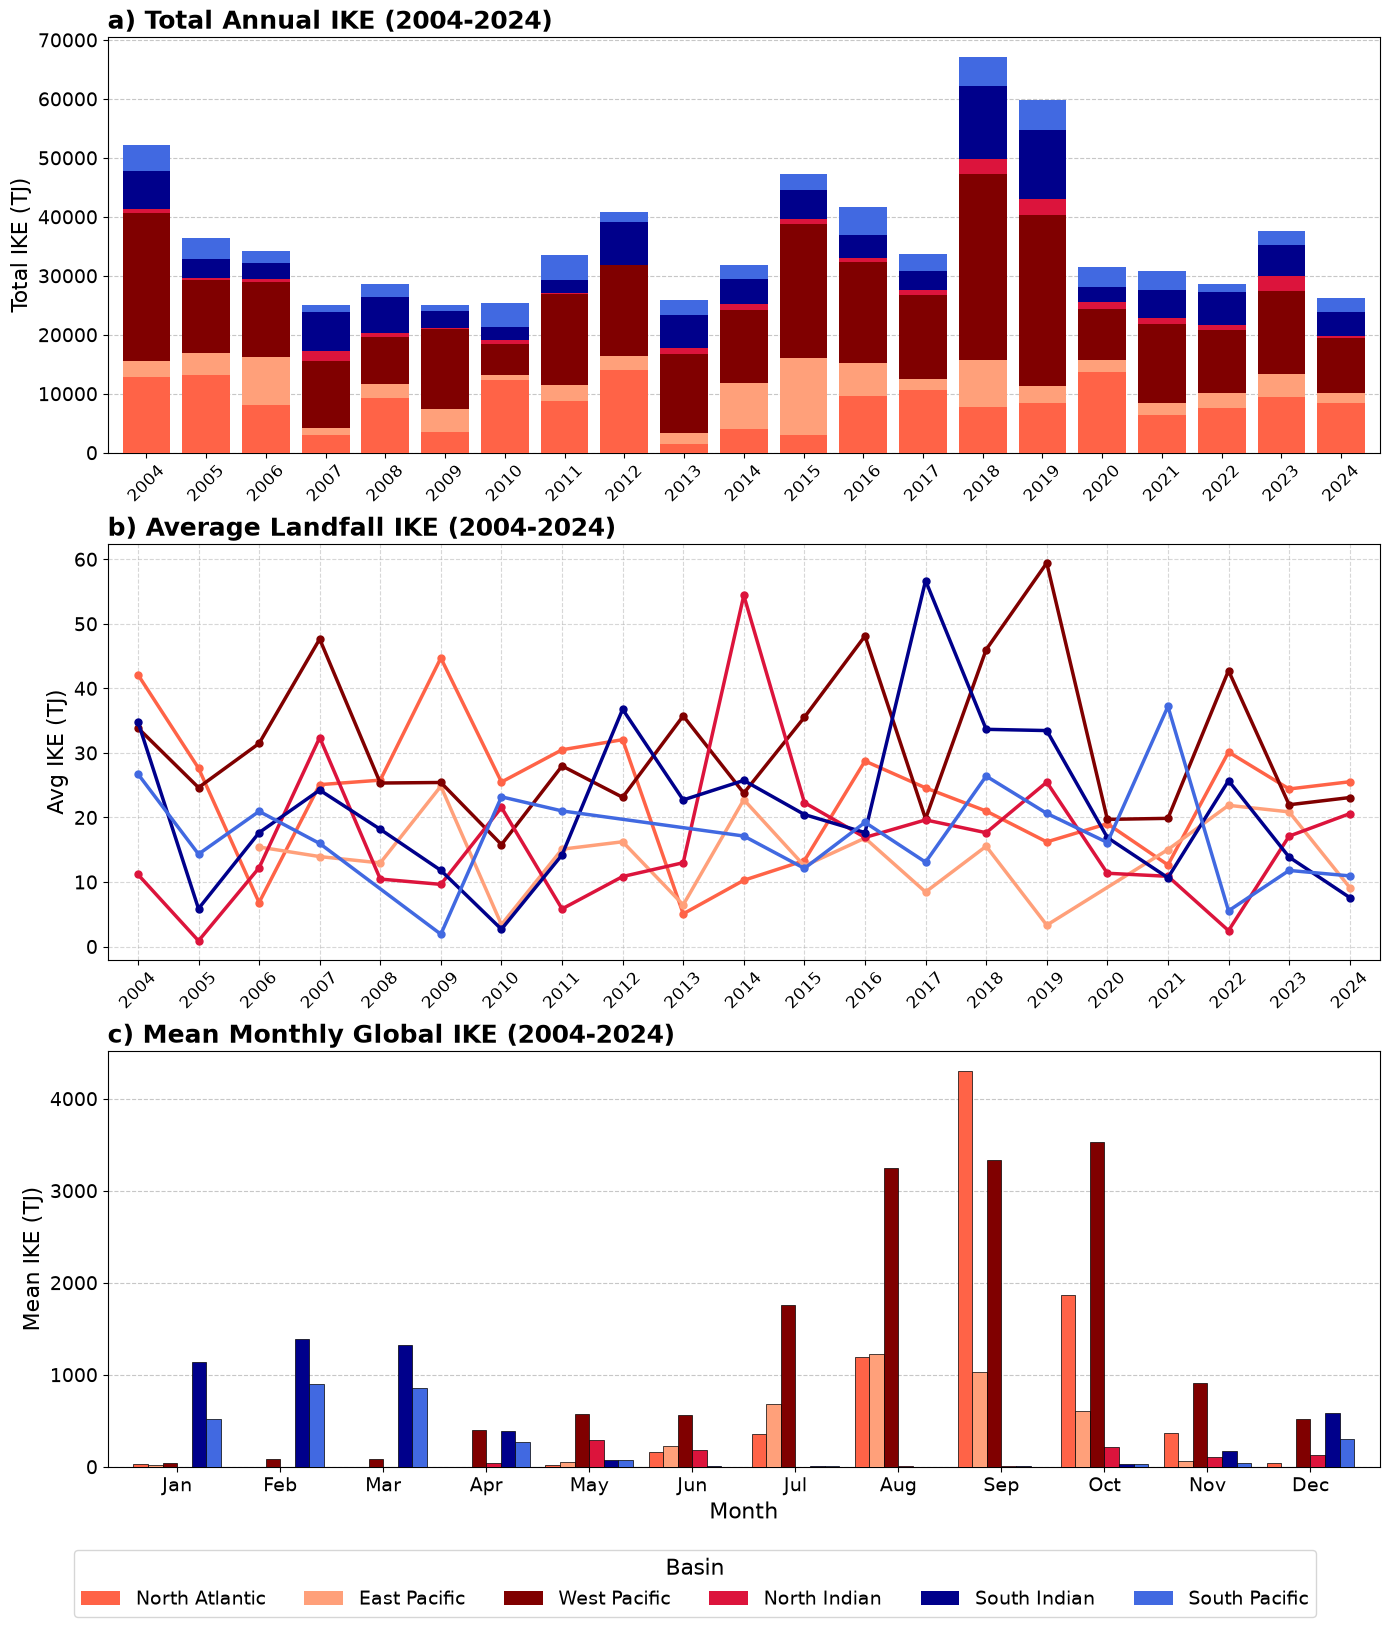

In [5]:
df_metrics = annual_metrics.sort_values(by="storm_year")
years = df_metrics["storm_year"].unique()
year_range = [int(years.min()), int(years.max())]

fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=False)

# --- Panel (a): Total Annual IKE - stacked bar -------------------------
ax = axes[0]
df_plot_a = df_metrics.groupby(["storm_year", "basin"])["annual_total_ike"].sum().unstack()
current_basins_a = [b for b in DESIRED_BASIN_ORDER if b in df_plot_a.columns]
df_plot_a = df_plot_a[current_basins_a]
plot_colors_a = [BASIN_COLORS.get(b, "gray") for b in df_plot_a.columns]
df_plot_a.plot(
    kind="bar", stacked=True, ax=ax, width=0.8,
    color=plot_colors_a, zorder=10, legend=False,
)
ax.set_title(f"a) Total Annual IKE ({year_range[0]}-{year_range[1]})",
             fontsize=18, weight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Total IKE (TJ)", fontsize=16)
ax.grid(True, linestyle="--", alpha=0.7, axis="y")
ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.tick_params(axis="y", labelsize=14)

# --- Panel (b): Average Landfall IKE - line plot -------------------------
ax = axes[1]
for basin in DESIRED_BASIN_ORDER:
    basin_data = (
        df_metrics[df_metrics["basin"] == basin]
        .sort_values("storm_year")
        .dropna(subset=["annual_avg_landfall_ike"])
    )
    if not basin_data.empty:
        ax.plot(
            basin_data["storm_year"], basin_data["annual_avg_landfall_ike"],
            color=BASIN_COLORS[basin], linewidth=2.5, marker="o",
            markersize=5, label=basin,
        )
ax.set_title(f"b) Average Landfall IKE ({year_range[0]}-{year_range[1]})",
             fontsize=18, weight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Avg IKE (TJ)", fontsize=16)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(axis="y", labelsize=14)
ax.set_xticks(np.arange(year_range[0], year_range[1] + 1, 1))
ax.tick_params(axis="x", rotation=45, labelsize=12)
ax.set_xlim(year_range[0] - 0.5, year_range[1] + 0.5)

# --- Panel (c): Mean Monthly Global IKE - grouped bar --------------------
ax = axes[2]
temp_df = master_df.copy()
temp_df["month"] = temp_df.index.month
# Sum all IKE for each basin/month across the whole period, then divide by
# the number of years to get the true climatological mean per year.
monthly_sum = temp_df.groupby(["month", "basin"])["total_ike_tj"].sum().reset_index()
num_years = temp_df["storm_year"].nunique()
monthly_sum["mean_monthly_ike"] = monthly_sum["total_ike_tj"] / num_years
df_plot_c = monthly_sum.pivot(index="month", columns="basin", values="mean_monthly_ike").fillna(0)
df_plot_c = df_plot_c.reindex(range(1, 13), fill_value=0)  # ensure all 12 months appear
df_plot_c.index = [calendar.month_abbr[m] for m in df_plot_c.index]
current_basins_c = [b for b in DESIRED_BASIN_ORDER if b in df_plot_c.columns]
df_plot_c = df_plot_c[current_basins_c]
plot_colors_c = [BASIN_COLORS.get(b, "gray") for b in df_plot_c.columns]
df_plot_c.plot(
    kind="bar", stacked=False, ax=ax, width=0.85,
    color=plot_colors_c, edgecolor="black", linewidth=0.5, zorder=5,
    legend=False,
)
ax.set_title(f"c) Mean Monthly Global IKE ({year_range[0]}-{year_range[1]})",
             fontsize=18, weight="bold", loc="left")
ax.set_xlabel("Month", fontsize=16)
ax.set_ylabel("Mean IKE (TJ)", fontsize=16)
ax.grid(True, linestyle="--", alpha=0.7, axis="y")
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", labelsize=14)

# --- Single unified legend -----------------------------------------------
legend_handles = [Patch(facecolor=BASIN_COLORS[b], label=b) for b in DESIRED_BASIN_ORDER]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=6, title="Basin",
    fontsize=14, title_fontsize=16, bbox_to_anchor=(0.5, -0.02), frameon=True,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
os.makedirs(config.BASE_OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(config.BASE_OUTPUT_DIR, "combined_ike_3panel.png"),
            dpi=300, bbox_inches="tight")
plt.show()